# FraudShield — Exploratory Data Analysis
**Dataset:** IEEE-CIS Fraud Detection (Kaggle)  
**Goal:** Understand the data distribution, class imbalance, missing value patterns, and which features carry signal — so our feature engineering in Step 4 is grounded in evidence, not guesswork.

## 0. Setup
The Kaggle dataset folder should be inside `data/raw/`:
```
data/raw/ieee-fraud-detection/train_transaction.csv
data/raw/ieee-fraud-detection/train_identity.csv
```
Download from: https://www.kaggle.com/competitions/ieee-fraud-detection/data

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

DATA_RAW = '../data/raw/ieee-fraud-detection'
TRANS_PATH = os.path.join(DATA_RAW, 'train_transaction.csv')
IDENT_PATH = os.path.join(DATA_RAW, 'train_identity.csv')

assert os.path.exists(TRANS_PATH), f'Missing: {TRANS_PATH}'
assert os.path.exists(IDENT_PATH), f'Missing: {IDENT_PATH}'
print('Files found — loading...')

Files found — loading...


## 1. Load Data

In [2]:
trans = pd.read_csv(TRANS_PATH)
ident = pd.read_csv(IDENT_PATH)

print(f'Transactions : {trans.shape[0]:,} rows × {trans.shape[1]} cols')
print(f'Identity     : {ident.shape[0]:,} rows × {ident.shape[1]} cols')

Transactions : 590,540 rows × 394 cols
Identity     : 144,233 rows × 41 cols


In [3]:
# Merge on TransactionID — identity is optional (not every transaction has identity info)
df = trans.merge(ident, on='TransactionID', how='left')
print(f'Merged shape : {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Identity join rate: {ident.shape[0] / trans.shape[0]:.1%}')
df.head(3)

Merged shape : 590,540 rows × 434 cols
Identity join rate: 24.4%


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Class Distribution — The Imbalance Problem

In [4]:
fraud_counts = df['isFraud'].value_counts()
fraud_rate = df['isFraud'].mean()

print(f'Legitimate transactions : {fraud_counts[0]:,} ({1 - fraud_rate:.2%})')
print(f'Fraudulent transactions : {fraud_counts[1]:,} ({fraud_rate:.2%})')
print(f'Imbalance ratio         : {fraud_counts[0] / fraud_counts[1]:.0f}:1')

Legitimate transactions : 569,877 (96.50%)
Fraudulent transactions : 20,663 (3.50%)
Imbalance ratio         : 28:1


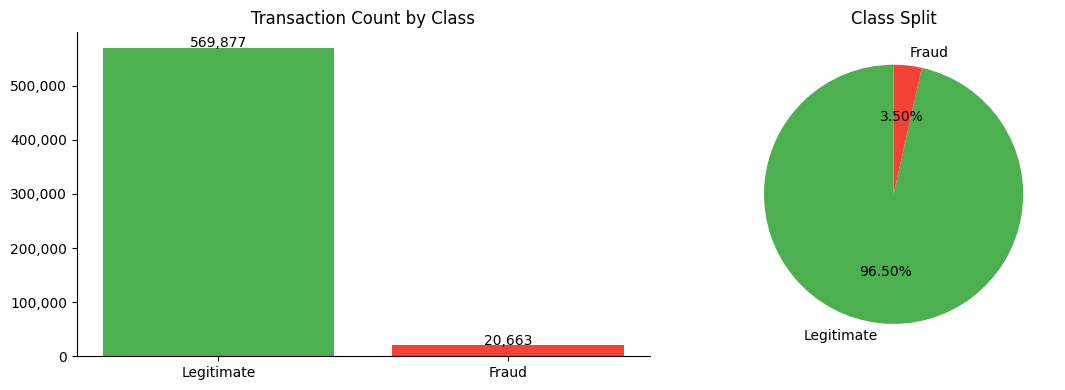


IMPACT: ~3.5% fraud rate means accuracy is a useless metric.
We will optimize for PR-AUC (Precision-Recall), which punishes false negatives harder.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values, color=['#4CAF50', '#F44336'])
axes[0].set_title('Transaction Count by Class')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

axes[1].pie([1 - fraud_rate, fraud_rate], labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%', colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title('Class Split')

plt.tight_layout()
plt.savefig('../docs/eda_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nIMPACT: ~3.5% fraud rate means accuracy is a useless metric.')
print('We will optimize for PR-AUC (Precision-Recall), which punishes false negatives harder.')

## 3. Transaction Amount Analysis

In [6]:
legit = df[df['isFraud'] == 0]['TransactionAmt']
fraud = df[df['isFraud'] == 1]['TransactionAmt']

print('TransactionAmt stats:')
print(pd.DataFrame({
    'Legitimate': legit.describe(),
    'Fraud': fraud.describe()
}).round(2))

TransactionAmt stats:
       Legitimate     Fraud
count   569877.00  20663.00
mean       134.51    149.24
std        239.40    232.21
min          0.25      0.29
25%         43.97     35.04
50%         68.50     75.00
75%        120.00    161.00
max      31937.39   5191.00


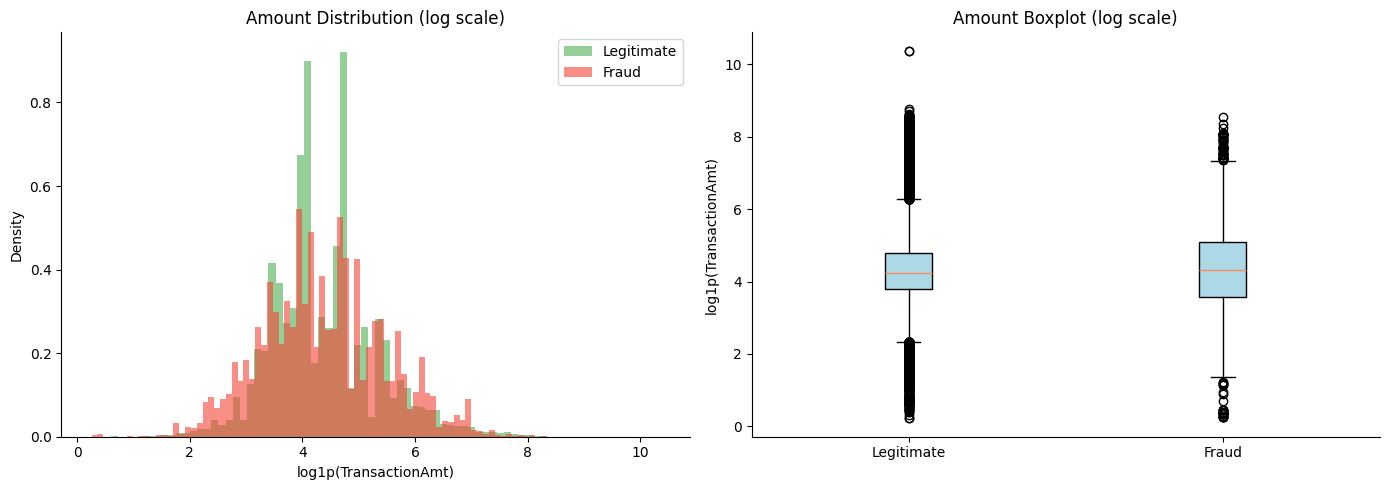


INSIGHT: Fraud skews toward higher amounts, but there is heavy overlap.
Amount alone is not enough — we need engineered features (velocity, z-score vs user history).


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale distribution
axes[0].hist(np.log1p(legit), bins=80, alpha=0.6, label='Legitimate', color='#4CAF50', density=True)
axes[0].hist(np.log1p(fraud), bins=80, alpha=0.6, label='Fraud', color='#F44336', density=True)
axes[0].set_xlabel('log1p(TransactionAmt)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution (log scale)')
axes[0].legend()

# Boxplot
axes[1].boxplot([np.log1p(legit), np.log1p(fraud)],
                labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_ylabel('log1p(TransactionAmt)')
axes[1].set_title('Amount Boxplot (log scale)')

plt.tight_layout()
plt.savefig('../docs/eda_amount_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nINSIGHT: Fraud skews toward higher amounts, but there is heavy overlap.')
print('Amount alone is not enough — we need engineered features (velocity, z-score vs user history).')

## 4. Time-Based Patterns

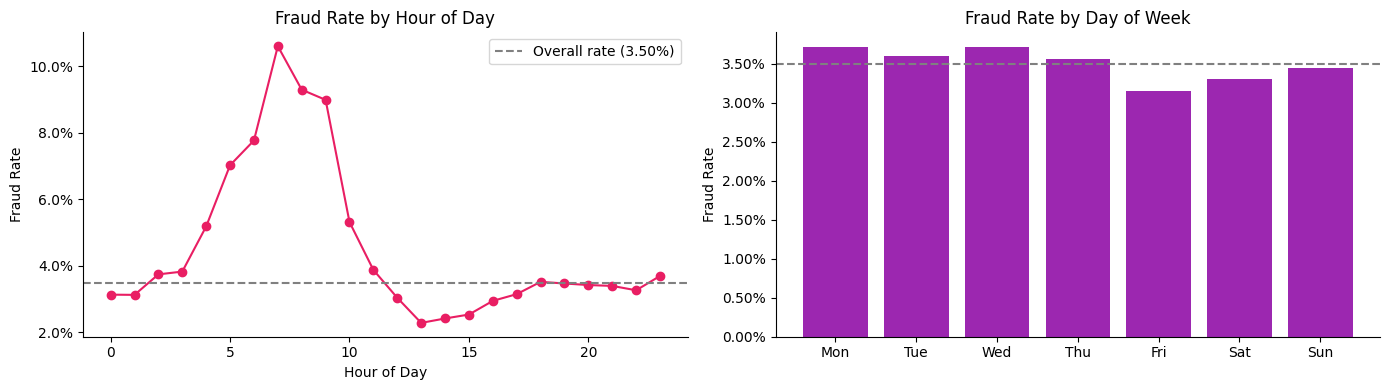


INSIGHT: Fraud rates vary by hour — late night typically spikes.
hour_of_day and day_of_week are strong feature engineering candidates.


In [8]:
# TransactionDT is seconds elapsed from a reference point (not a real timestamp)
df['hour_of_day'] = (df['TransactionDT'] // 3600) % 24
df['day_of_week'] = (df['TransactionDT'] // 86400) % 7

hourly_fraud_rate = df.groupby('hour_of_day')['isFraud'].mean()
daily_fraud_rate = df.groupby('day_of_week')['isFraud'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hourly_fraud_rate.index, hourly_fraud_rate.values, marker='o', color='#E91E63')
axes[0].axhline(fraud_rate, linestyle='--', color='gray', label=f'Overall rate ({fraud_rate:.2%})')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend()

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(days, daily_fraud_rate.values, color='#9C27B0')
axes[1].axhline(fraud_rate, linestyle='--', color='gray')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_title('Fraud Rate by Day of Week')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('../docs/eda_time_patterns.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nINSIGHT: Fraud rates vary by hour — late night typically spikes.')
print('hour_of_day and day_of_week are strong feature engineering candidates.')

## 5. Missing Value Analysis

In [9]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

print(f'Columns with missing values: {len(missing)} / {df.shape[1]}')
print(f'Columns with >50% missing  : {(missing > 50).sum()}')
print(f'Columns with >90% missing  : {(missing > 90).sum()}')
print()
print('Top 20 most missing:')
print(missing.head(20).to_string())

Columns with missing values: 414 / 436
Columns with >50% missing  : 214
Columns with >90% missing  : 12

Top 20 most missing:
id_24    99.196159
id_25    99.130965
id_08    99.127070
id_07    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
D9       87.312290


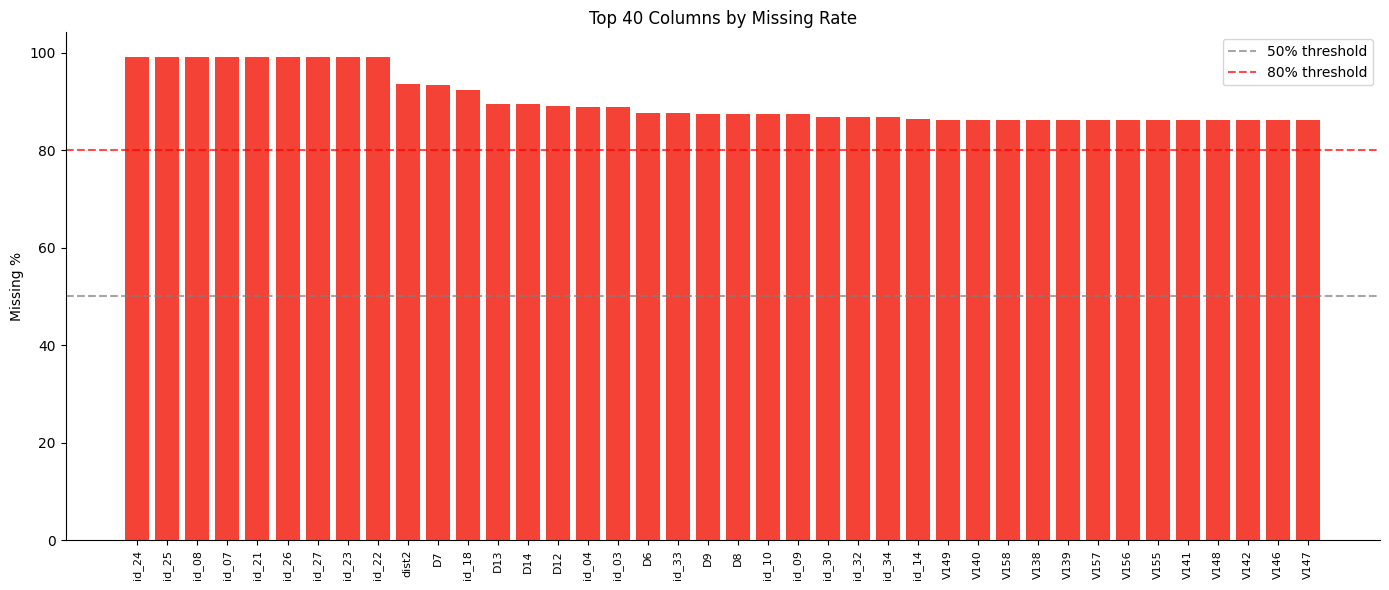


STRATEGY: Drop cols >90% missing. For V-features (Vesta-engineered), median-impute.
Never impute with mean when skewed — use median.


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
top_missing = missing.head(40)
colors = ['#F44336' if v > 80 else '#FF9800' if v > 50 else '#FFC107' for v in top_missing.values]
ax.bar(range(len(top_missing)), top_missing.values, color=colors)
ax.set_xticks(range(len(top_missing)))
ax.set_xticklabels(top_missing.index, rotation=90, fontsize=8)
ax.axhline(50, linestyle='--', color='gray', alpha=0.7, label='50% threshold')
ax.axhline(80, linestyle='--', color='red', alpha=0.7, label='80% threshold')
ax.set_ylabel('Missing %')
ax.set_title('Top 40 Columns by Missing Rate')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/eda_missing_values.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nSTRATEGY: Drop cols >90% missing. For V-features (Vesta-engineered), median-impute.')
print('Never impute with mean when skewed — use median.')

## 6. Categorical Feature Analysis

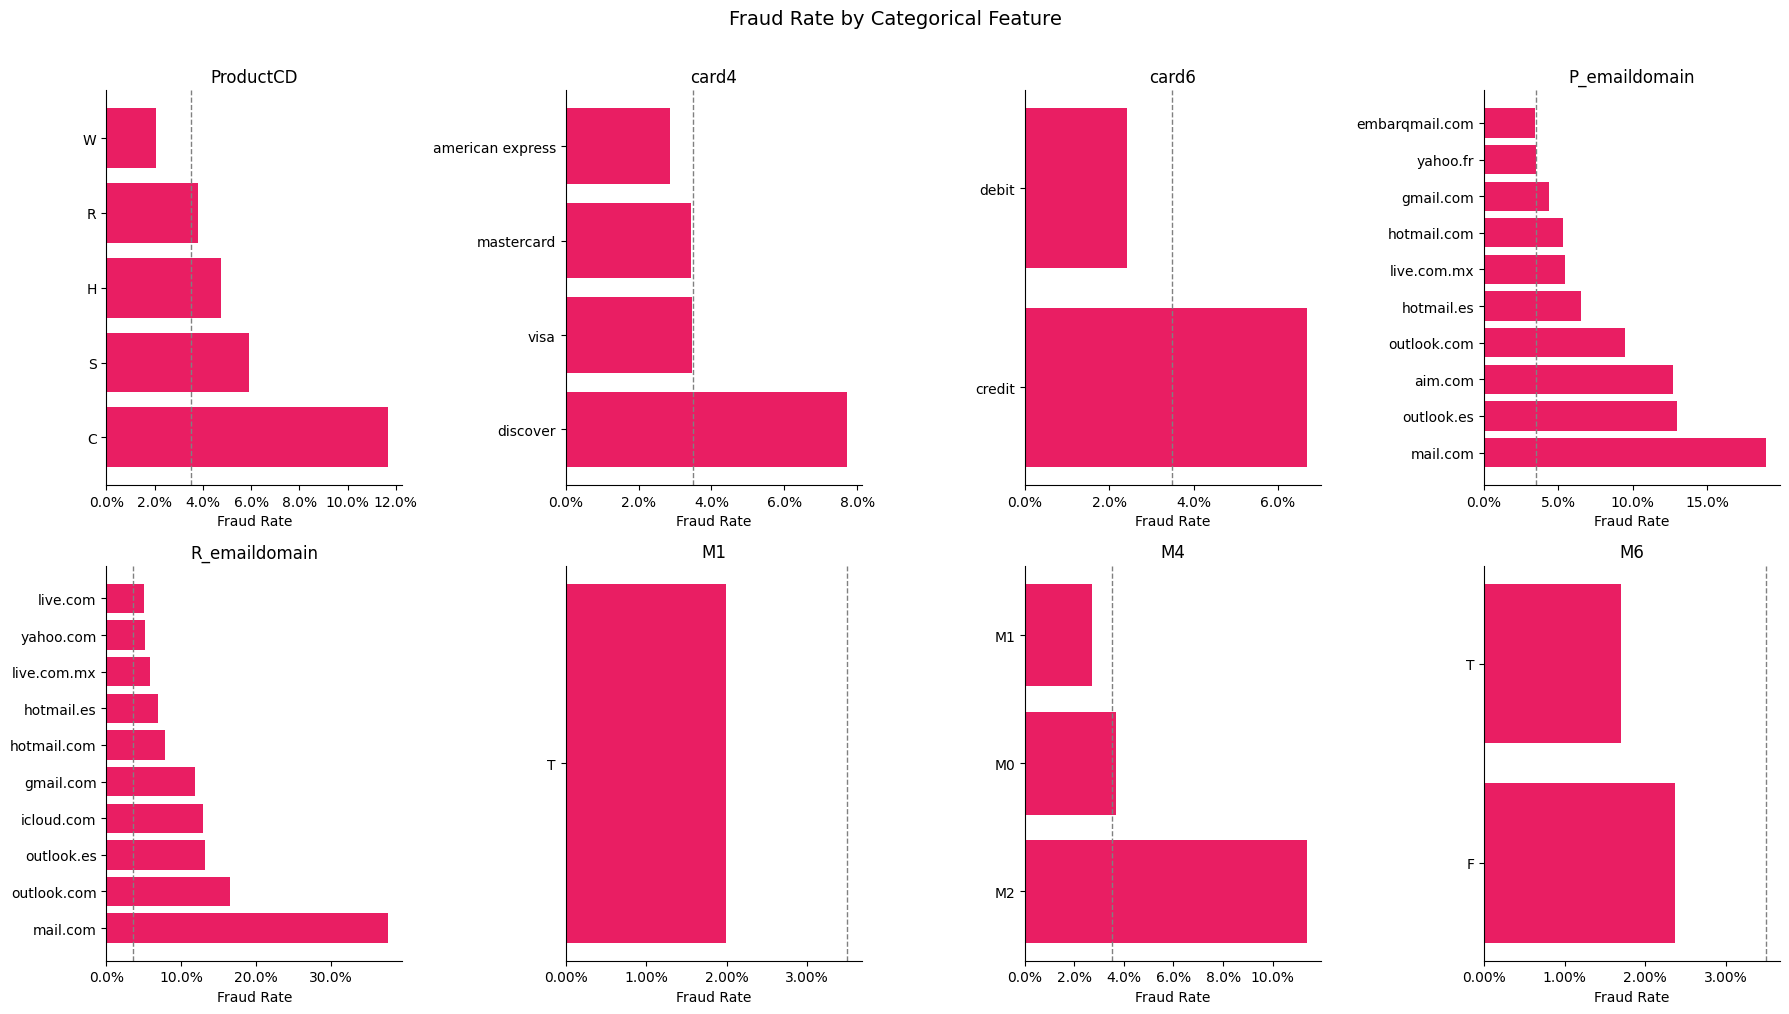


INSIGHT: Certain email domains and card types have significantly higher fraud rates.
These are prime candidates for target encoding in Step 4.


In [11]:
cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M4', 'M6']
cat_cols = [c for c in cat_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    fraud_by_cat = df.groupby(col)['isFraud'].agg(['mean', 'count']).reset_index()
    fraud_by_cat = fraud_by_cat[fraud_by_cat['count'] >= 100]  # filter rare categories
    fraud_by_cat = fraud_by_cat.sort_values('mean', ascending=False).head(10)
    
    bars = axes[i].barh(fraud_by_cat[col].astype(str), fraud_by_cat['mean'], color='#E91E63')
    axes[i].axvline(fraud_rate, linestyle='--', color='gray', linewidth=1)
    axes[i].set_title(col)
    axes[i].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[i].set_xlabel('Fraud Rate')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Fraud Rate by Categorical Feature', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../docs/eda_categorical_fraud_rates.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nINSIGHT: Certain email domains and card types have significantly higher fraud rates.')
print('These are prime candidates for target encoding in Step 4.')

## 7. V-Feature Correlation with Fraud

In [12]:
# The dataset has V1-V339 Vesta-engineered features — find which ones correlate with fraud
v_cols = [c for c in df.columns if c.startswith('V')]
print(f'Total V-features: {len(v_cols)}')

# Correlation with target — only for columns with <50% missing
v_missing = (df[v_cols].isnull().mean())
v_valid = v_missing[v_missing < 0.5].index.tolist()
print(f'V-features with <50% missing: {len(v_valid)}')

v_corr = df[v_valid + ['isFraud']].corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)
print(f'\nTop 20 V-features by |correlation| with isFraud:')
print(v_corr.head(20).to_string())

Total V-features: 339
V-features with <50% missing: 180



Top 20 V-features by |correlation| with isFraud:
V45    0.281832
V44    0.260376
V86    0.251828
V87    0.251737
V52    0.239469
V51    0.223191
V40    0.212442
V39    0.203097
V38    0.199005
V43    0.198274
V79    0.194141
V42    0.189428
V94    0.188407
V74    0.185915
V33    0.183486
V17    0.182673
V18    0.182550
V81    0.182377
V93    0.180983
V92    0.180513


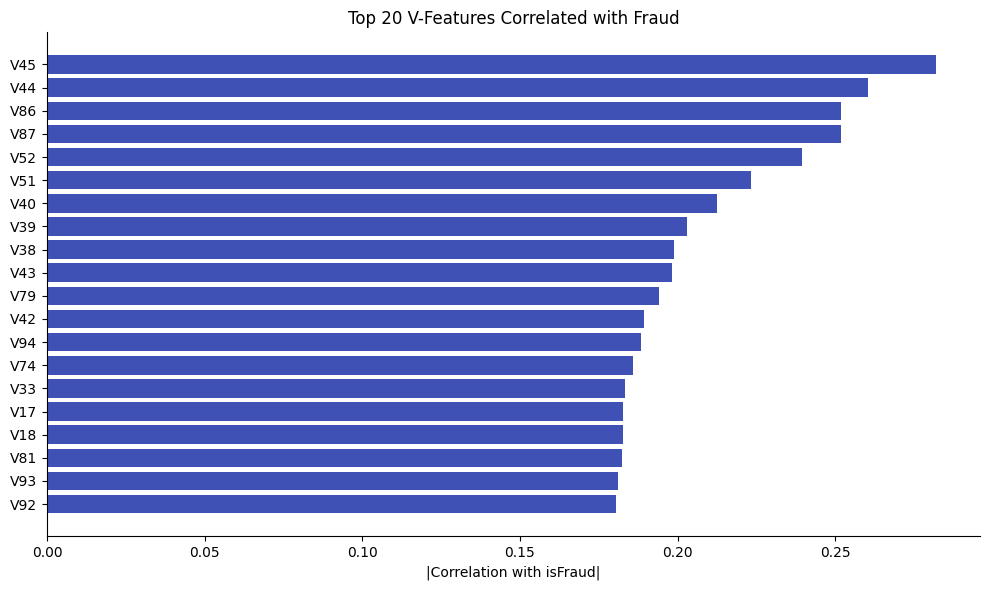


INSIGHT: A small subset of V-features carry most of the signal.
We will select top V-features by correlation + feature importance after model training.


In [13]:
top_v = v_corr.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_v.index[::-1], top_v.values[::-1], color='#3F51B5')
plt.xlabel('|Correlation with isFraud|')
plt.title('Top 20 V-Features Correlated with Fraud')
plt.tight_layout()
plt.savefig('../docs/eda_v_feature_correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nINSIGHT: A small subset of V-features carry most of the signal.')
print('We will select top V-features by correlation + feature importance after model training.')

## 8. Card & Address Feature Analysis

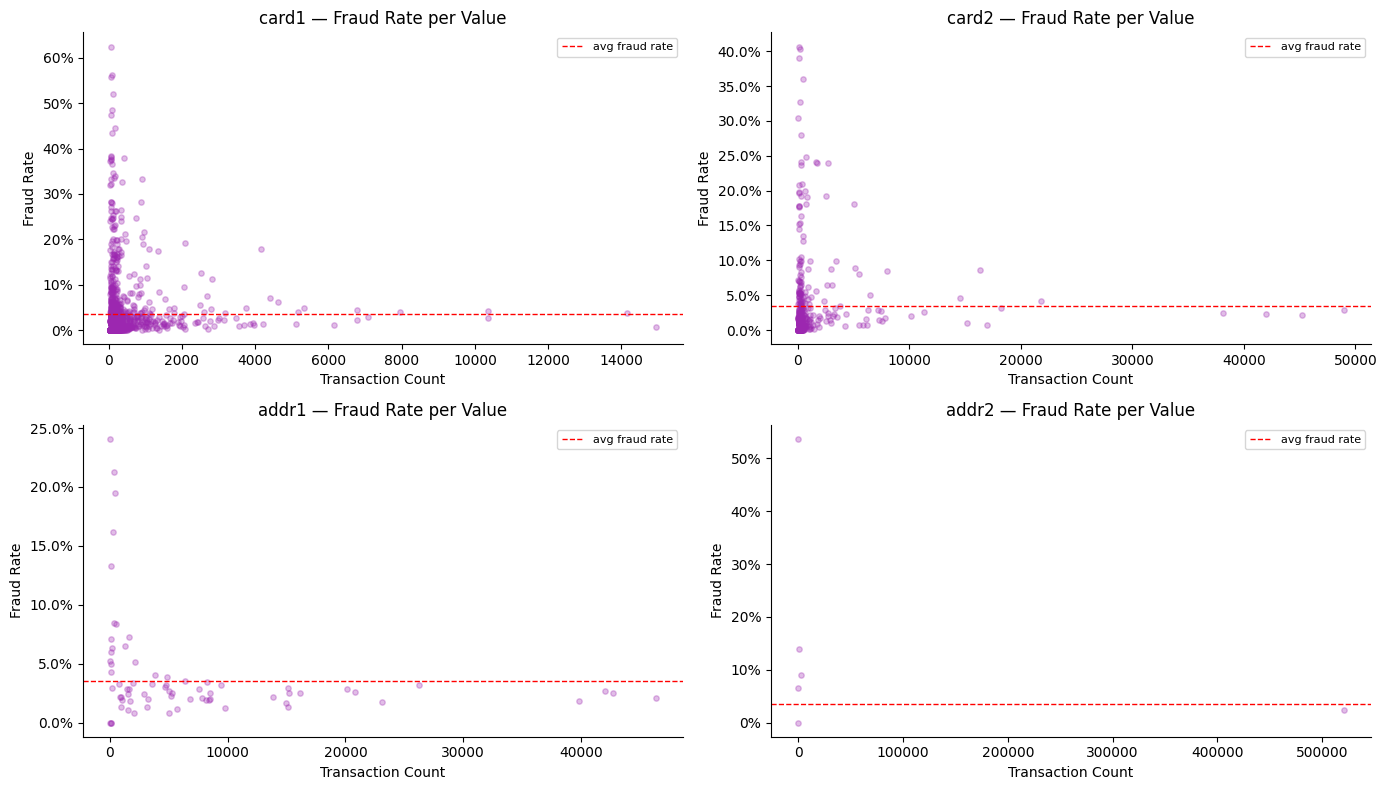


INSIGHT: Some card/address combinations are consistently high-risk.
We will build velocity features: txn count per card in last 1h/24h/7d.


In [14]:
# card1-card6 encode card type/bank/etc — they're IDs, not raw numerics
# addr1/addr2 are billing address fields

card_addr = ['card1', 'card2', 'addr1', 'addr2']
card_addr = [c for c in card_addr if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(card_addr):
    fraud_by = df.groupby(col)['isFraud'].agg(['mean', 'count'])
    fraud_by = fraud_by[fraud_by['count'] >= 50]  # at least 50 txns
    
    axes[i].scatter(fraud_by['count'], fraud_by['mean'],
                    alpha=0.3, s=15, color='#9C27B0')
    axes[i].axhline(fraud_rate, linestyle='--', color='red', linewidth=1, label='avg fraud rate')
    axes[i].set_xlabel('Transaction Count')
    axes[i].set_ylabel('Fraud Rate')
    axes[i].set_title(f'{col} — Fraud Rate per Value')
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../docs/eda_card_addr_fraud.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nINSIGHT: Some card/address combinations are consistently high-risk.')
print('We will build velocity features: txn count per card in last 1h/24h/7d.')

## 9. Identity Features (from train_identity.csv)

In [15]:
# Only ~47% of transactions have identity data
# These features add signal but we can't require them

has_identity = df['id_01'].notna()
print(f'Transactions with identity data: {has_identity.sum():,} ({has_identity.mean():.1%})')
print()
print('Fraud rate comparison:')
print(f'  With identity    : {df[has_identity]["isFraud"].mean():.3%}')
print(f'  Without identity : {df[~has_identity]["isFraud"].mean():.3%}')

Transactions with identity data: 144,233 (24.4%)

Fraud rate comparison:


  With identity    : 7.847%


  Without identity : 2.094%


In [16]:
# DeviceType is a particularly interesting feature
if 'DeviceType' in df.columns:
    device_fraud = df.groupby('DeviceType')['isFraud'].agg(['mean', 'count']).reset_index()
    print('Fraud rate by DeviceType:')
    print(device_fraud.to_string(index=False))
    print('\nINSIGHT: Desktop vs mobile fraud rates often differ significantly.')

Fraud rate by DeviceType:
DeviceType     mean  count
   desktop 0.065215  85165
    mobile 0.101662  55645

INSIGHT: Desktop vs mobile fraud rates often differ significantly.


## 10. Key Findings Summary

In [17]:
print('='*65)
print('FRAUDSHIELD EDA — KEY FINDINGS')
print('='*65)
print()
print(f'Dataset size    : {df.shape[0]:,} transactions × {df.shape[1]} features')
print(f'Fraud rate      : {fraud_rate:.2%} → severe class imbalance')
print(f'Imbalance ratio : {(1-fraud_rate)/fraud_rate:.0f}:1 (use PR-AUC, not accuracy/ROC-AUC)')
print()
print('Missing data')
print(f'  {(missing > 90).sum()} cols with >90% missing → DROP these')
print(f'  {(missing > 50).sum()} cols with >50% missing → consider dropping')
print(f'  Remaining V-features → median impute')
print()
print('Feature engineering plan for Step 4:')
print('  1. hour_of_day, day_of_week         (time periodicity)')
print('  2. log1p(TransactionAmt)             (tame the skew)')
print('  3. amt_zscore_per_card               (anomaly vs user history)')
print('  4. txn_count_card1_1h / 24h / 7d    (velocity features via Redis)')
print('  5. target_encode(card4, card6, P_emaildomain)')
print('  6. top V-features by correlation     (select ~50 from 339)')
print('  7. has_identity flag                 (proxy for channel type)')
print()
print('Model strategy:')
print('  - XGBoost or LightGBM (handles missing natively)')
print('  - scale_pos_weight = (legit count / fraud count) to handle imbalance')
print('  - Tune threshold at inference for precision/recall tradeoff')
print('  - Target: PR-AUC > 0.85')
print('='*65)

FRAUDSHIELD EDA — KEY FINDINGS

Dataset size    : 590,540 transactions × 436 features
Fraud rate      : 3.50% → severe class imbalance
Imbalance ratio : 28:1 (use PR-AUC, not accuracy/ROC-AUC)

Missing data
  12 cols with >90% missing → DROP these
  214 cols with >50% missing → consider dropping
  Remaining V-features → median impute

Feature engineering plan for Step 4:
  1. hour_of_day, day_of_week         (time periodicity)
  2. log1p(TransactionAmt)             (tame the skew)
  3. amt_zscore_per_card               (anomaly vs user history)
  4. txn_count_card1_1h / 24h / 7d    (velocity features via Redis)
  5. target_encode(card4, card6, P_emaildomain)
  6. top V-features by correlation     (select ~50 from 339)
  7. has_identity flag                 (proxy for channel type)

Model strategy:
  - XGBoost or LightGBM (handles missing natively)
  - scale_pos_weight = (legit count / fraud count) to handle imbalance
  - Tune threshold at inference for precision/recall tradeoff
  - Tar